In [1]:
import os
import sys
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath('..'))   # repo root: utils, metrics

from esrgan import RRDBNet, Discriminator, VGGPerceptual, perceptual_loss, ragan_d_loss, ragan_g_loss
from utils.utils import return_device, return_photos
from utils.metrics import reconstruction_metrics

In [2]:
device = return_device()

Device is cuda


In [3]:
PATH_TO_PHOTOS = '../../archive/lfw-deepfunneled'
HR_SIZE=128

all_photos = return_photos(PATH_TO_PHOTOS, size=HR_SIZE)

100%|██████████| 13233/13233 [00:17<00:00, 764.56it/s]

Photos uploaded: 13233


In [4]:
SCALE = 4   # x4: 128 -> 32 low-res. Use 2 for x2 (128 -> 64).
batch_size = 16

train_photos, val_photos = train_test_split(all_photos, train_size=0.9, shuffle=True)
train_loader = torch.utils.data.DataLoader(train_photos, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_photos, batch_size=batch_size)

# ESRGAN

Single-image super-resolution: take a low-resolution face and reconstruct a high-resolution one with realistic texture.

Two ideas from the ESRGAN paper on top of plain SRGAN: the generator uses **RRDB** blocks (residual-in-residual dense, no BatchNorm), and the discriminator is **relativistic** (judges how much more realistic a real image is than a fake, not an absolute real/fake score). Generator loss = L1 + perceptual (VGG, pre-activation) + relativistic adversarial.

In [5]:
def make_lr(hr, scale=SCALE):
    lr = F.interpolate(hr, scale_factor = 1/scale, mode='bicubic', align_corners=False)
    return lr.clamp(0, 1)

modelG = RRDBNet(scale=SCALE, n_blocks=16).to(device)
modelD = Discriminator().to(device)
vgg = VGGPerceptual().to(device)

optimizerG = torch.optim.Adam(modelG.parameters(), lr=1e-4, betas=(0.9, 0.999))
optimizerD = torch.optim.Adam(modelD.parameters(), lr=1e-4, betas=(0.9, 0.999))

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /home/jovyan/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:18<00:00, 31.7MB/s] 


## PSNR-oriented pretraining

ESRGAN first trains the generator with **L1 only** (no GAN, no perceptual). This gives a stable starting point — jumping straight into adversarial training from random weights produces artifacts. After this warmup, the full loss is switched on.

  0%|          | 0/10 [00:00<?, ?it/s]

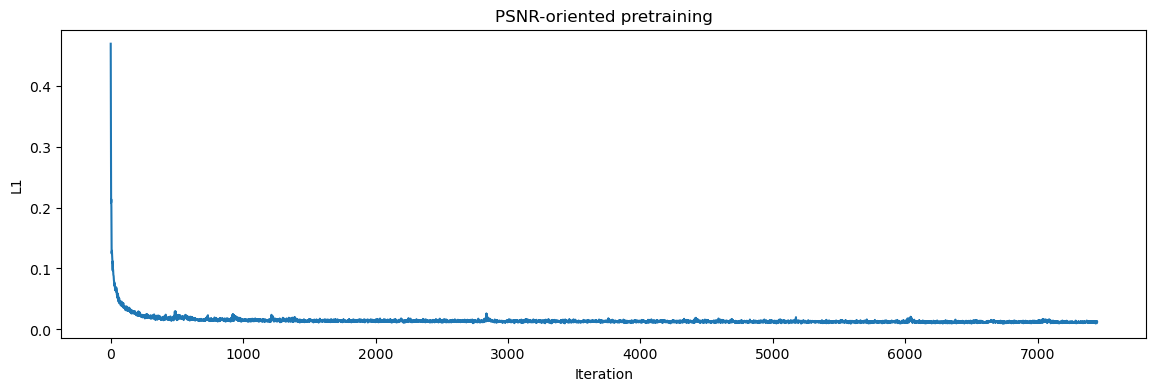

In [6]:
n_pretrain = 10
pre_losses = []
for epoch in tqdm(range(n_pretrain)):
    modelG.train()
    for hr in train_loader:
        hr = hr.permute(0, 3, 1, 2).to(device).float() / 255
        lr = make_lr(hr)
        sr = modelG(lr)
        loss = F.l1_loss(sr, hr)
        optimizerG.zero_grad()
        loss.backward()
        optimizerG.step()
        pre_losses.append(loss.item())

plt.figure(figsize=(14, 4))
plt.plot(pre_losses)
plt.xlabel('Iteration')
plt.ylabel('L1')
plt.title('PSNR-oriented pretraining')
plt.show()

## ESRGAN training

G loss = L1 + perceptual + relativistic adversarial. The discriminator is updated with the RaGAN loss.

Loss weights follow the paper (perceptual 1.0, adversarial 0.005, L1 0.01).

In [7]:
n_epochs = 50
w_l1, w_percep, w_adv = 1e-2, 1.0, 5e-3

loss_L1, loss_P, loss_Gadv, loss_D = [], [], [], []
for epoch in tqdm(range(n_epochs)):
    modelG.train()
    modelD.train()
    for hr in train_loader:
        hr = hr.permute(0, 3, 1, 2).to(device).float() / 255
        lr = make_lr(hr)
        sr = modelG(lr)

        # Discriminator (relativistic)
        optimizerD.zero_grad()
        d_real = modelD(hr)
        d_fake = modelD(sr.detach())
        d_loss = ragan_d_loss(d_real, d_fake)
        d_loss.backward()
        optimizerD.step()

        # Generator
        optimizerG.zero_grad()
        d_real = modelD(hr).detach()  # real branch detached for G
        d_fake = modelD(sr)
        l1 = F.l1_loss(sr, hr)
        percep = perceptual_loss(vgg, sr.clamp(0, 1), hr)
        g_adv = ragan_g_loss(d_real, d_fake)
        g_loss = w_l1 * l1 + w_percep * percep + w_adv * g_adv
        g_loss.backward()
        optimizerG.step()

        loss_L1.append(l1.item())
        loss_P.append(percep.item())
        loss_Gadv.append(g_adv.item())
        loss_D.append(d_loss.item())

  0%|          | 0/50 [00:00<?, ?it/s]

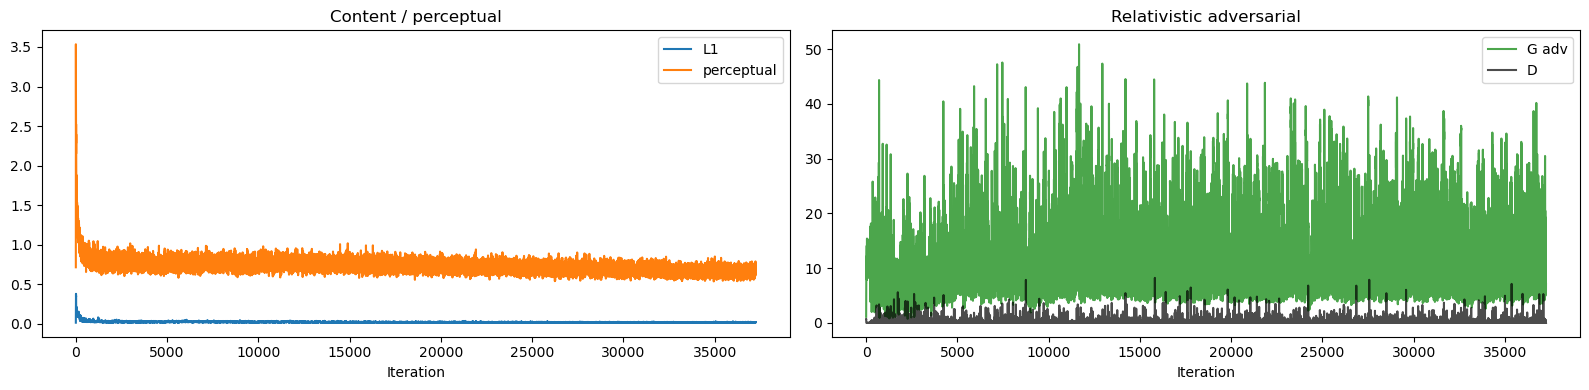

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
ax1.plot(loss_L1, label='L1')
ax1.plot(loss_P, label='perceptual')
ax1.legend()
ax1.set_xlabel('Iteration')
ax1.set_title('Content / perceptual')
ax2.plot(loss_Gadv, label='G adv', color='green', alpha=0.7)
ax2.plot(loss_D, label='D', color='black', alpha=0.7)
ax2.legend()
ax2.set_xlabel('Iteration')
ax2.set_title('Relativistic adversarial')
plt.tight_layout()
plt.show()

## Results — LR vs SR vs HR

The low-res input is shown upsampled with plain bicubic (what you'd get without a model) next to the network's output and the ground-truth high-res image.

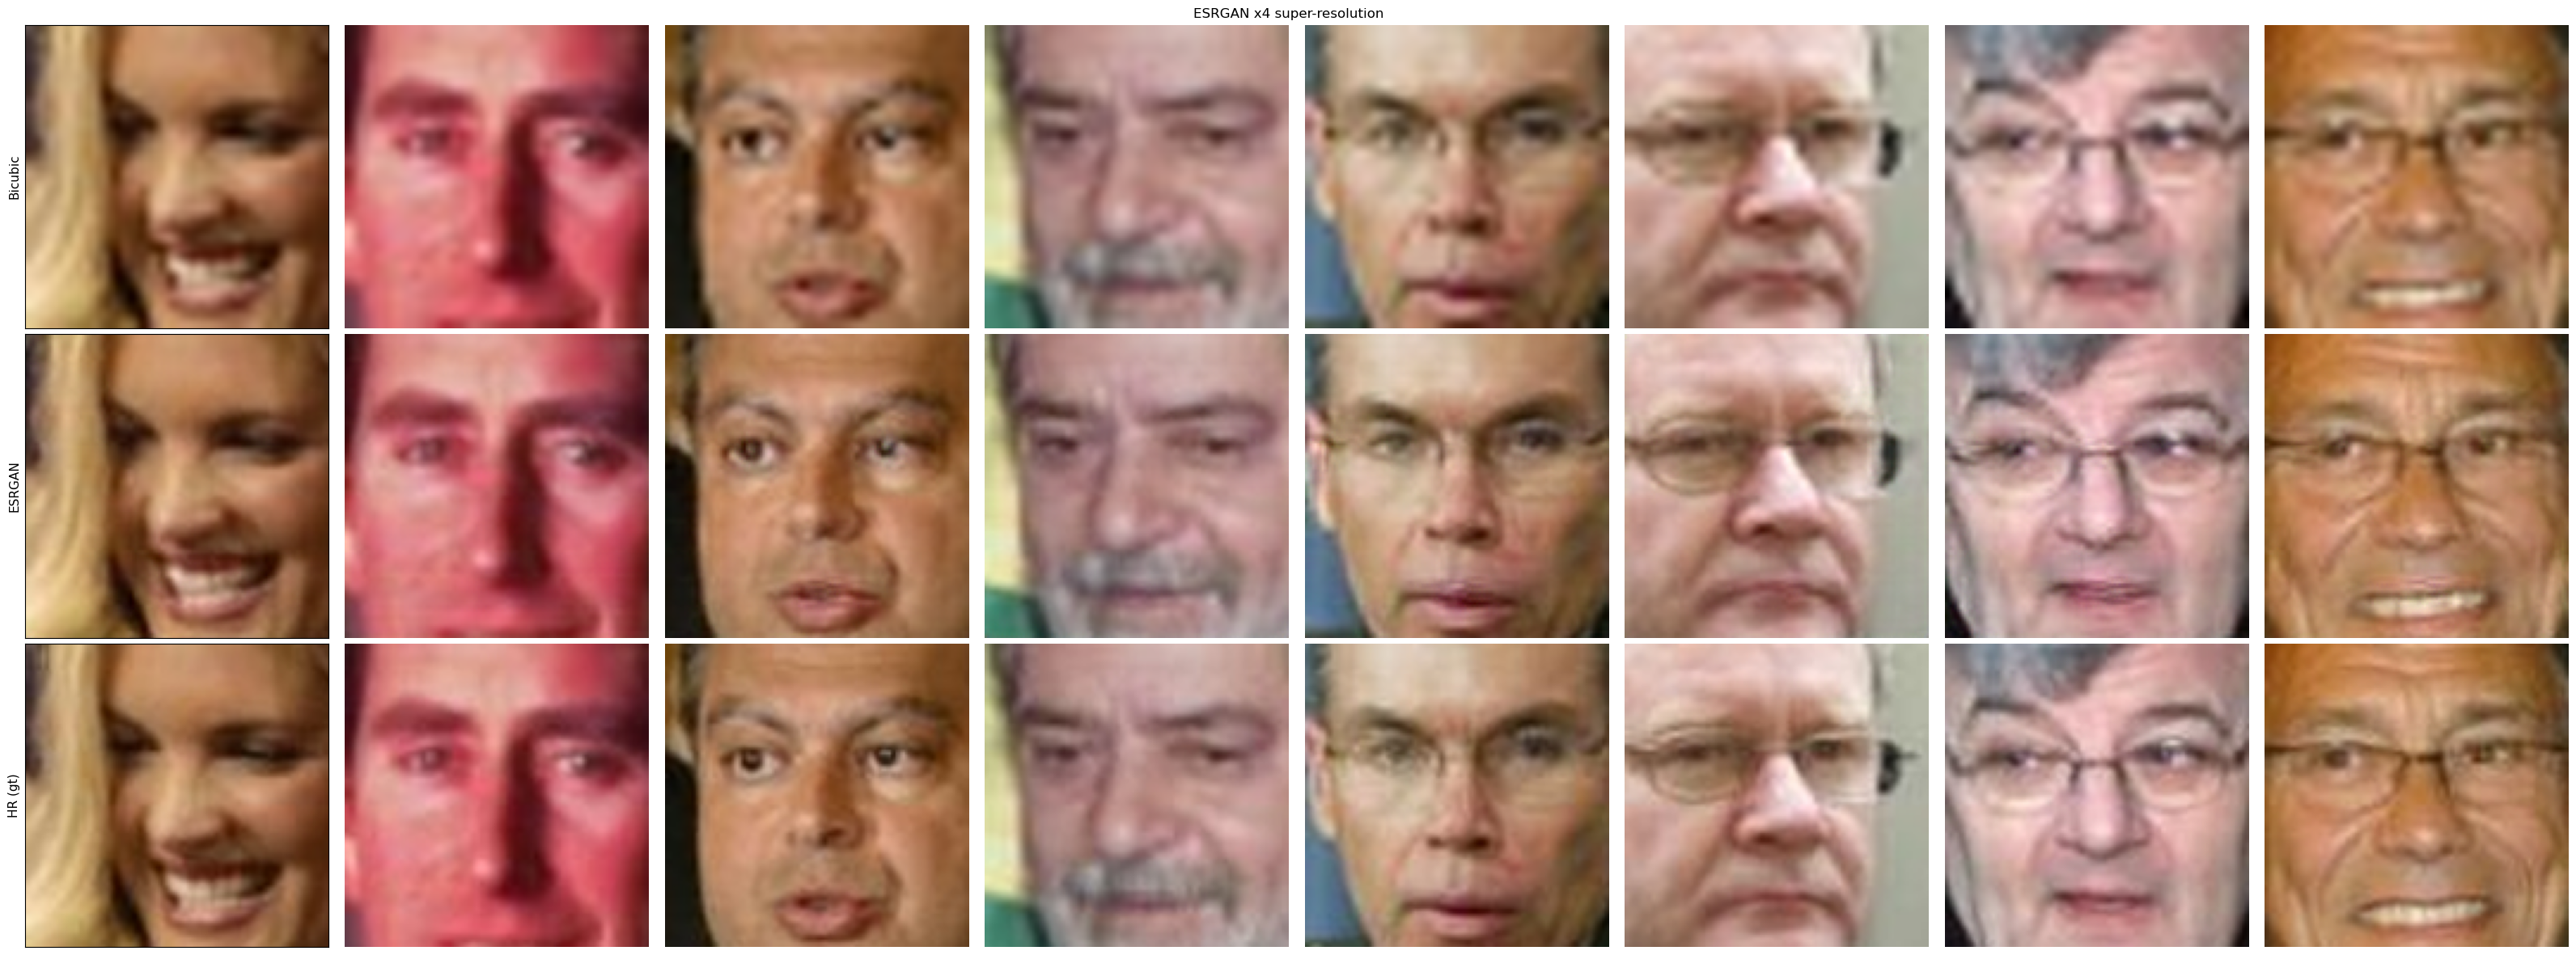

In [11]:
modelG.eval()
with torch.no_grad():
    hr = next(iter(val_loader)).permute(0, 3, 1, 2).to(device).float() / 255
    lr = make_lr(hr)
    sr = modelG(lr).clamp(0, 1)
    lr_bicubic = F.interpolate(lr, size=hr.shape[-2:], mode='bicubic', align_corners=False).clamp(0, 1)

n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 12))
for i in range(n_show):
    axes[0, i].imshow(lr_bicubic[i].cpu().permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    axes[1, i].imshow(sr[i].cpu().permute(1, 2, 0).numpy())
    axes[1, i].axis('off')
    axes[2, i].imshow(hr[i].cpu().permute(1, 2, 0).numpy())
    axes[2, i].axis('off')
axes[0, 0].set_ylabel('Bicubic', fontsize=11)
axes[0, 0].axis('on')
axes[0, 0].set_xticks([])
axes[0, 0].set_yticks([])
axes[1, 0].set_ylabel('ESRGAN', fontsize=11)
axes[1, 0].axis('on')
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])
axes[2, 0].set_ylabel('HR (gt)', fontsize=11)
axes[2, 0].axis('on')
axes[2, 0].set_xticks([])
axes[2, 0].set_yticks([])
plt.suptitle('ESRGAN x{} super-resolution'.format(SCALE))
plt.tight_layout()
plt.show()

In [13]:
#  PSNR/SSIM/LPIPS of the super-resolved output against the HR ground truth. For inference only the generator is needed.

modelG.eval()
origs, recons = [], []
with torch.no_grad():
    for hr in val_loader:
        hr = hr.permute(0, 3, 1, 2).to(device).float() / 255
        sr = modelG(make_lr(hr)).clamp(0, 1)
        origs.append(hr.cpu())
        recons.append(sr.cpu())
origs, recons = torch.cat(origs), torch.cat(recons)
print(reconstruction_metrics(origs, recons))

torch.save(modelG.state_dict(), '../checkpoints/esrgan_generator.pt')

Device is cuda
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /opt/conda/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
{'PSNR': 32.914039611816406, 'SSIM': 0.994468092918396, 'LPIPS': 0.03300424665212631}
